# 🚗 Detector de Placas Vehiculares con YOLOv8
> **Curso:** Inteligencia Artificial Avanzada — UNAB Digital  
> **Modelo:** YOLOv8n (obligatorio para AWS por limitación de memoria)  
> **Dataset:** placa-de-carro-sxy3a (Roboflow)

⚠️ **ANTES DE EMPEZAR:** Activa la GPU: `Entorno de ejecución → Cambiar tipo → T4`

---
## PASO 1 — Verificar GPU

In [ ]:
import torch

if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}')
    print(f'💾 Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('❌ No se detectó GPU. Ve a Entorno de ejecución > Cambiar tipo > T4')

✅ GPU: Tesla T4
💾 Memoria: 15.6 GB


---
## PASO 2 — Instalar dependencias

In [ ]:
!pip install ultralytics roboflow easyocr -q

import os, cv2, shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import easyocr

print('✅ Dependencias instaladas e importadas correctamente')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 32.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settin

---
## PASO 3 — Descargar dataset desde Roboflow
> Dataset de placas vehiculares colombianas — 836 imágenes, 1 clase: `placa`

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key='dSMfDD4uPaMCKEoGOP5q')
project = rf.workspace('cicatriz').project('placa-de-carro-sxy3a')
version = project.version(4)
dataset = version.download('yolov8', location='/content/dataset', overwrite=True)

print(f'\n✅ Dataset descargado en: {dataset.location}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset in yolov8:: 100%|██████████| 1677/1677 [00:00<00:00, 3337.93it/s]


✅ Dataset descargado en: /content/dataset


---
## PASO 4 — Verificar estructura del dataset

In [ ]:
import yaml

BASE_PATH = '/content/dataset'
yaml_path = os.path.join(BASE_PATH, 'data.yaml')

print('📂 Estructura del dataset:')
print('-' * 50)
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(BASE_PATH, split, 'images')
    if os.path.exists(img_dir):
        n = len(os.listdir(img_dir))
        print(f'  {split:<10} — {n:>4} imágenes')

if os.path.exists(yaml_path):
    print('\n📄 data.yaml:')
    print('-' * 40)
    with open(yaml_path) as f:
        print(f.read())
else:
    print('⚠️ No se encontró data.yaml')

📂 Estructura del dataset:
--------------------------------------------------
  train      —  674 imágenes
  valid      —  110 imágenes
  test       —   52 imágenes

📄 data.yaml:
----------------------------------------
names:
- placa
nc: 1
roboflow:
  license: CC BY 4.0
  project: placa-de-carro-sxy3a
  url: https://universe.roboflow.com/cicatriz/placa-de-carro-sxy3a/dataset/4
  version: 4
  workspace: cicatriz
test: ../test/images
train: ../train/images
val: ../valid/images



---
## PASO 5 — Entrenar el modelo YOLOv8
> ⏳ Este paso tarda entre 30 minutos y 1 hora. No cierres la pestaña.

> ⚠️ Usamos **yolov8n** (nano) porque es el más liviano y compatible con AWS.

In [ ]:
from ultralytics import YOLO

# Cargar YOLOv8 nano (obligatorio para AWS)
model = YOLO('yolov8n.pt')
print('✅ Modelo YOLOv8n cargado')
model.info()

✅ Modelo YOLOv8n cargado
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [ ]:
# Entrenar el modelo
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    project='/content/runs',
    name='placas_detector',
    save=True,
    patience=20,
    verbose=True
)

print('\n✅ Entrenamiento completado!')
print('📁 Modelo en: /content/runs/placas_detector/weights/best.pt')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=placas_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

---
## PASO 6 — Ver curvas de entrenamiento

📈 results.png


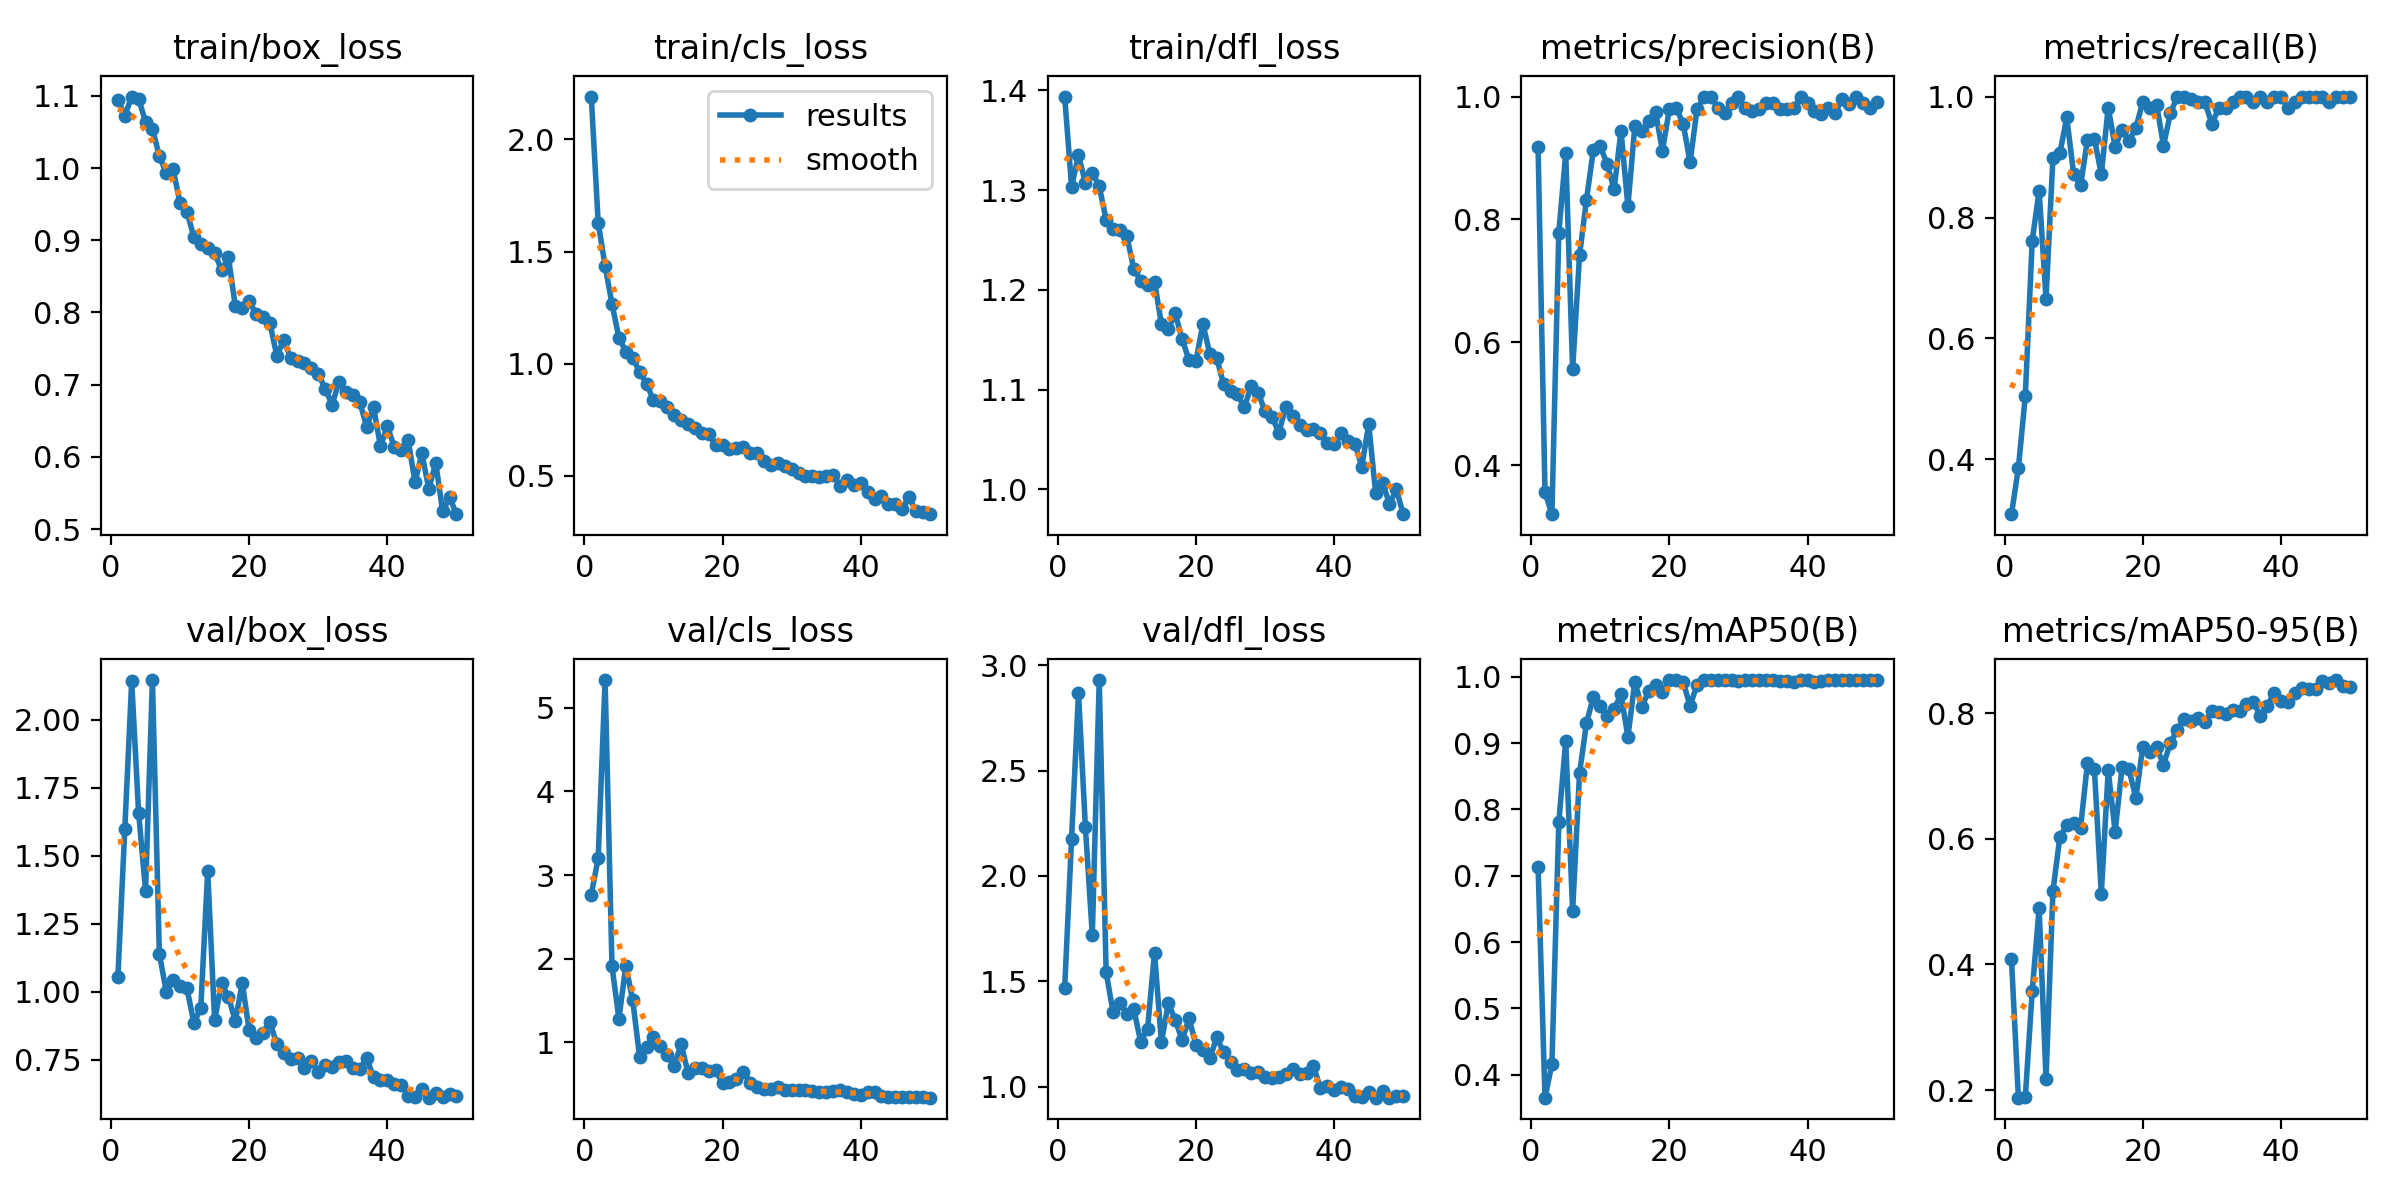

📈 confusion_matrix.png


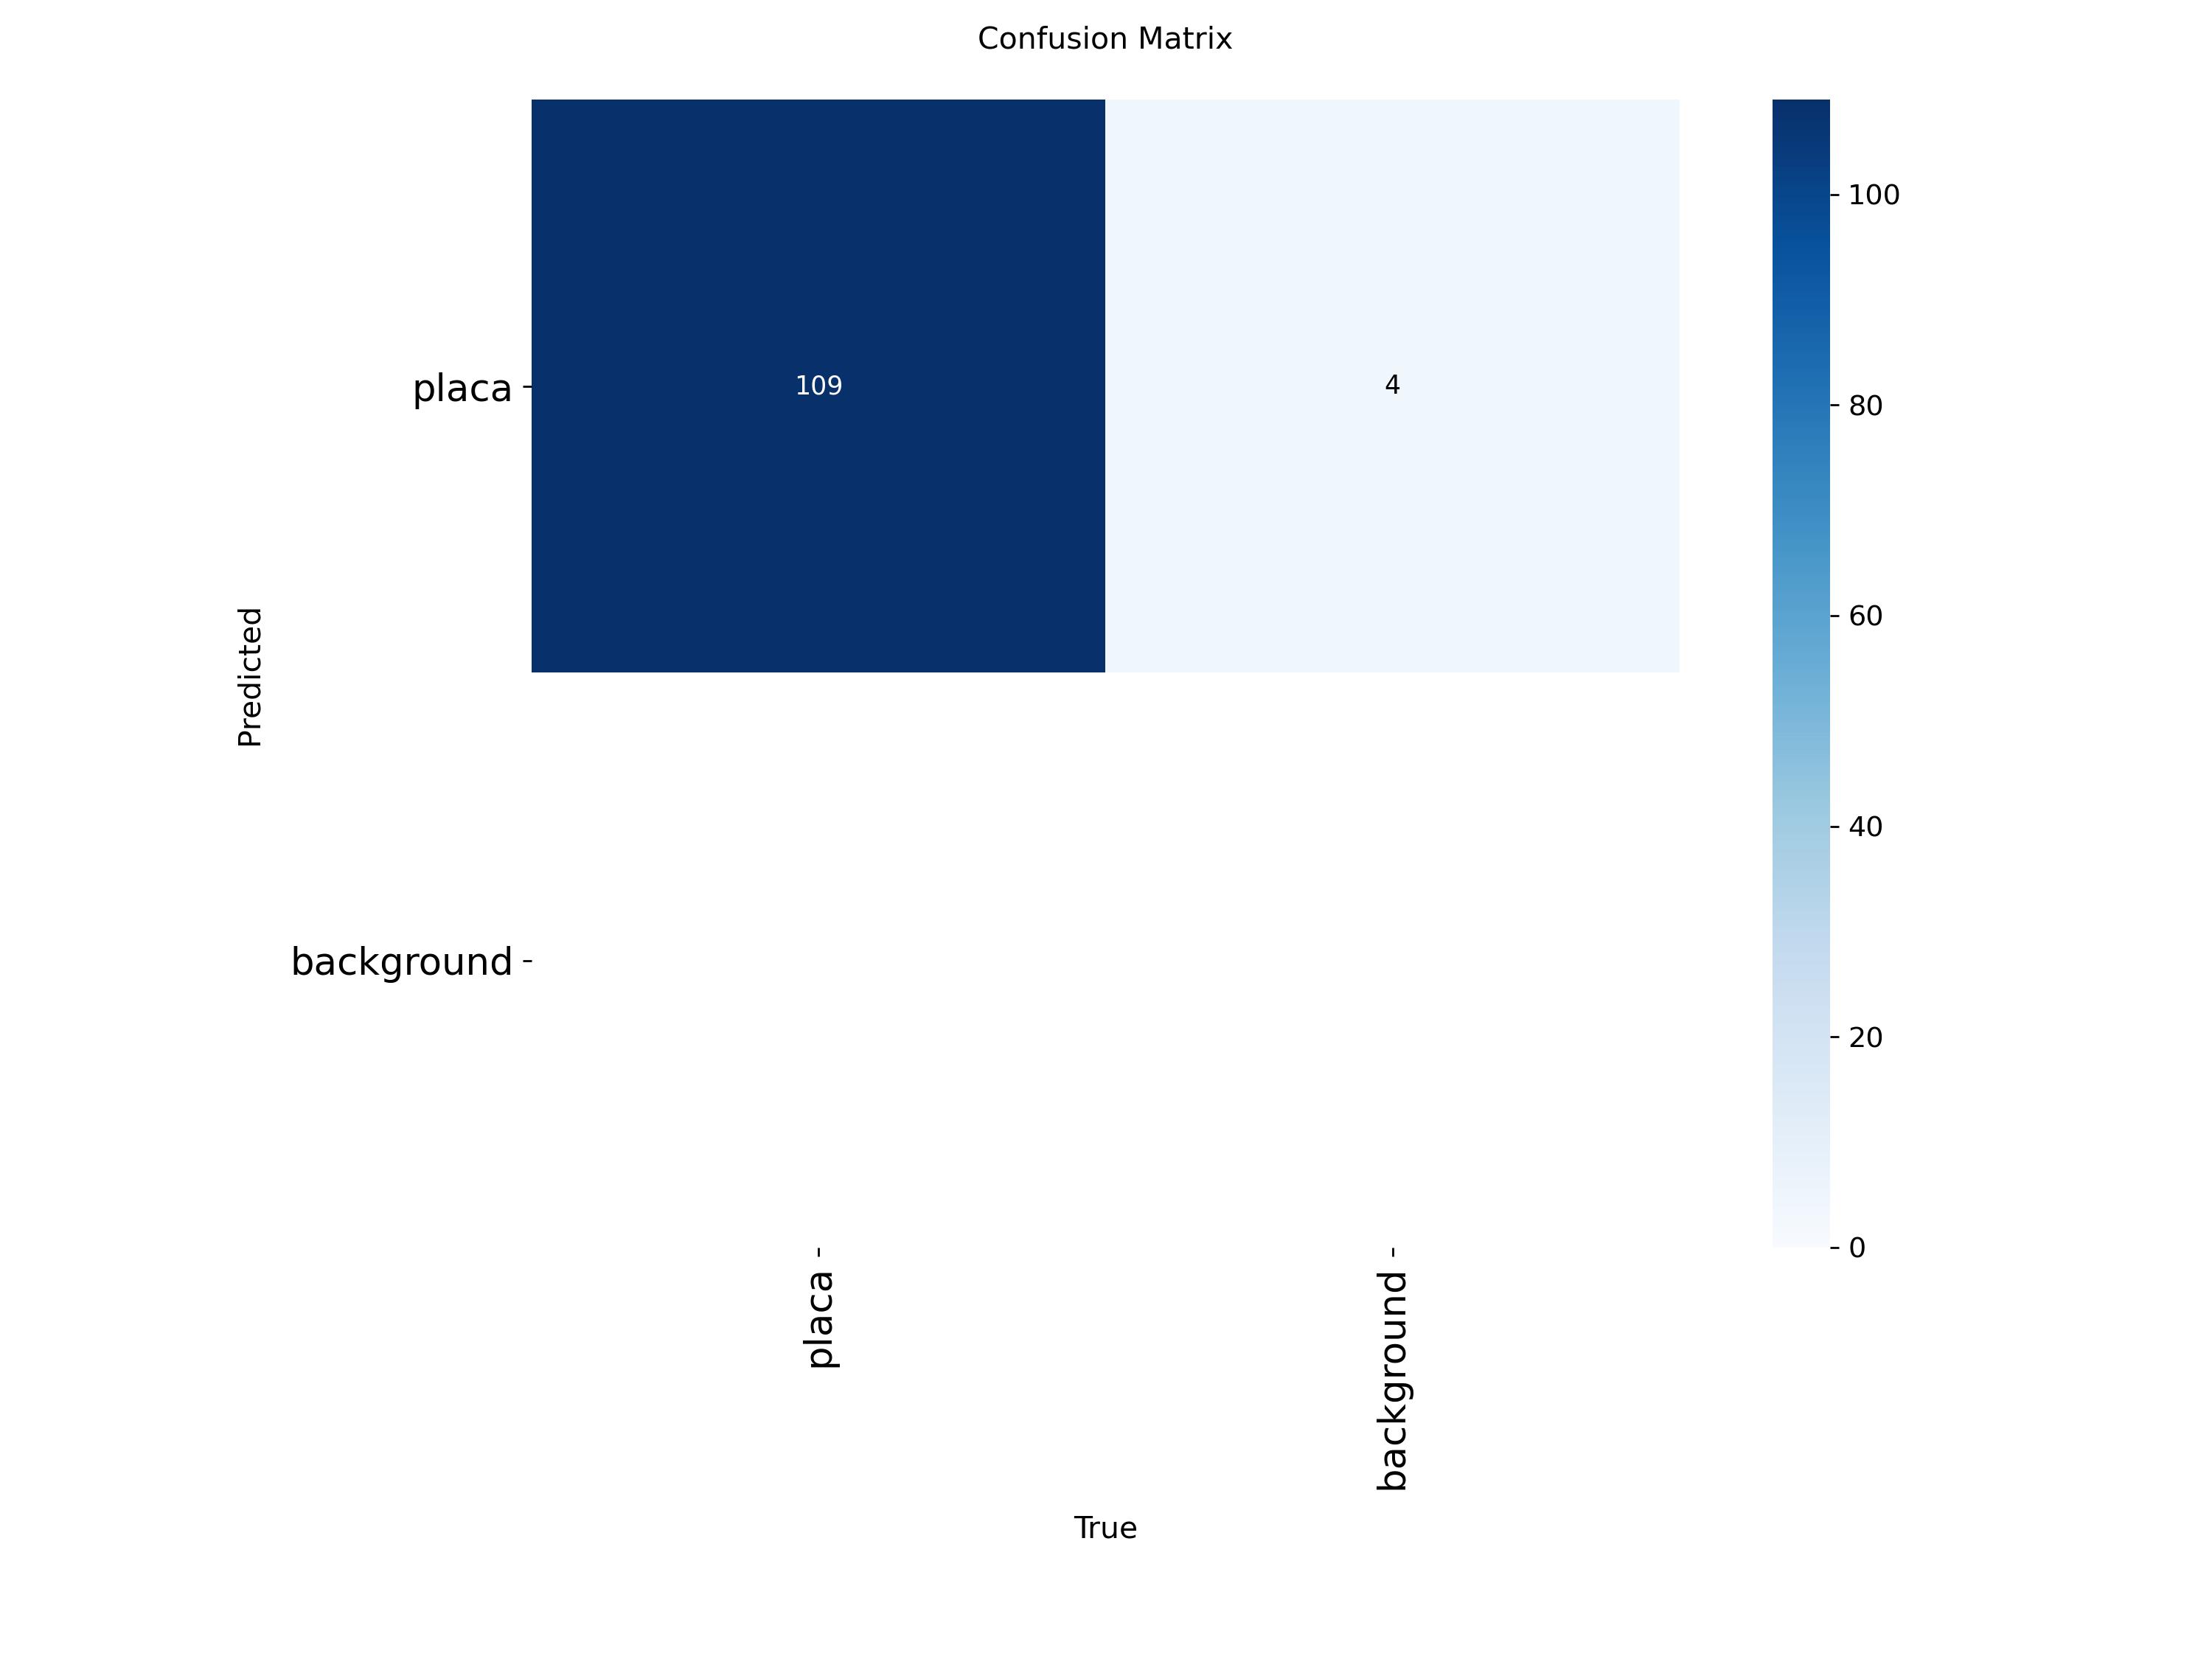

In [ ]:
from IPython.display import Image, display

train_dir = '/content/runs/placas_detector'
for plot in ['results.png', 'confusion_matrix.png', 'F1_curve.png']:
    path = os.path.join(train_dir, plot)
    if os.path.exists(path):
        print(f'📈 {plot}')
        display(Image(filename=path, width=700))

---
## PASO 7 — Evaluar el modelo

In [ ]:
model = YOLO('/content/runs/placas_detector/weights/best.pt')
metrics = model.val(data='/content/dataset/data.yaml')

print('\n📊 Resultados:')
print(f'  mAP50:    {metrics.box.map50:.3f}')
print(f'  mAP50-95: {metrics.box.map:.3f}')

---
## PASO 8 — Probar con imágenes de test

In [ ]:
import glob
from IPython.display import Image, display

test_images = glob.glob('/content/dataset/test/images/*.jpg')

if test_images:
    test_img = test_images[0]
    print(f'🖼️ Probando con: {test_img}')

    results = model.predict(
        source=test_img,
        conf=0.25,
        save=True,
        project='/content/runs',
        name='prueba'
    )

    saved = os.path.join(results[0].save_dir, os.path.basename(test_img))
    if os.path.exists(saved):
        display(Image(filename=saved, width=700))

    print(f'\n✅ Detecciones: {len(results[0].boxes)}')
else:
    print('⚠️ No se encontraron imágenes de test')

---
## PASO 9 — Probar OCR en una placa detectada
> Prueba de EasyOCR para leer el texto de la placa detectada

In [ ]:
import easyocr

# Inicializar lector OCR
reader = easyocr.Reader(['en'], gpu=True)
print('✅ EasyOCR inicializado')

if test_images:
    img_path = test_images[0]
    img = cv2.imread(img_path)

    # Detectar placa
    results = model.predict(source=img_path, conf=0.25, verbose=False)
    boxes = results[0].boxes

    if len(boxes) > 0:
        x1, y1, x2, y2 = map(int, boxes[0].xyxy[0])
        roi = img[max(0,y1):y2, max(0,x1):x2]

        # OCR sobre el recorte de la placa
        resultado_ocr = reader.readtext(roi)

        if resultado_ocr:
            texto = max(resultado_ocr, key=lambda x: x[2])[1]
            texto_limpio = ''.join(c for c in texto if c.isalnum()).upper()
            print(f'🚘 Placa detectada: {texto_limpio}')
        else:
            print('⚠️ OCR no pudo leer texto en la placa')
    else:
        print('⚠️ No se detectó ninguna placa en la imagen')

---
## PASO 10 — Descargar el modelo al PC
> Guarda `best.pt` en tu PC. Lo necesitarás para subir a AWS.

In [ ]:
from google.colab import files

model_path = '/content/runs/placas_detector/weights/best.pt'

if os.path.exists(model_path):
    print('⏳ Descargando best.pt...')
    files.download(model_path)
    print('✅ Descargado correctamente')
    print('\n👉 Guarda este archivo, lo necesitas para AWS')
else:
    print('❌ No se encontró best.pt. Completa el entrenamiento primero.')